<a href="https://colab.research.google.com/github/IsaganiJulian/Guardian-Recruit-Fraud-Detection/blob/feature%2Foutlier-modeling-week4-kusuma/03_outlier_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Outlier Detection for Job Fraud (Stream B)

## Objective
The goal of this notebook is to detect fraudulent job postings using anomaly detection techniques such as Isolation Forest and Local Outlier Factor (LOF).

## 1. Load Data

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
#os.listdir('/content/drive/MyDrive/DTSC 5082- Group 12 - Guardian Recruit')

In [3]:
#os.listdir('/content/drive/MyDrive/DTSC 5082- Group 12 - Guardian Recruit/data')

In [4]:
#os.listdir('/content/drive/MyDrive/DTSC 5082- Group 12 - Guardian Recruit/data/preprocessed')

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/train.csv")
df.head()

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
0,QA / BA entry level (Training and placement),"US, NJ, Piscataway",NaN,NaN,<p><i><b>Primesoft Inc</b></i><b> </b>is a fas...,<p><b>BA/ QA Entry Level positions</b> <b>(Tra...,<p><b>Job description: </b><b><br><br>We are l...,<p><b>What we offer:</b></p>\r\n<ul>\r\n<li>We...,f,t,f,Full-time,Entry level,NaN,Financial Services,Quality Assurance,f,f
1,Summer Internships,"PK, SD, Karachi",NaN,NaN,<p>The CSR Association of Pakistan serves as a...,"<p>As an Intern, you will be supporting cuttin...",<p><b>Who is eligible to participate?</b><br>T...,<p>Interns gain Insight to the world of CSR an...,f,t,t,Full-time,Internship,Bachelor's Degree,Civic & Social Organization,NaN,f,f
2,Consultant Doctor Opening in Saudi Arabia,"SA, 12, AL Hasa",Medicine,0-0,<h3><b>We the Medical Recruitment Team of Rola...,<p><b>Consultant Doctor Opening in Saudi Arabi...,<p><b>Requirements:</b></p>\r\n<p><b>Pediatric...,<p>Our Client is one of the reputed Health car...,f,t,f,NaN,Associate,Master's Degree,Hospital & Health Care,Health Care Provider,f,f
3,Digital Account Manager,"GB, CMD, London",Display,NaN,<p>Forward3D is the largest independent digita...,<p><b>In a nutshell:</b></p>\r\n<p>You will be...,<p><b>What you will need:</b></p>\r\n<ul>\r\n<...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,f,f
4,PeopleSoft HR Functional Lead,"US, MN, Minneapolis",IT,NaN,<p>ValleySoft is a fast growing global IT Serv...,<p>Responsibilities: <br><br>•Lead HR and Bene...,"<p>Skill PeopleSoft Core HR,Benefits Admin...",NaN,f,t,f,Contract,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,f,f


In [2]:
df.columns

Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'in_balanced_dataset'],
      dtype='object')

## 2. Feature Engineering

We convert raw data into numerical features suitable for machine learning models.

In [3]:
# Handle missing values

df['employment_type'] = df['employment_type'].fillna('Unknown')
df['required_education'] = df['required_education'].fillna('Unknown')

In [4]:
df.columns

Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'in_balanced_dataset'],
      dtype='object')

In [5]:
# Encode categorical variables

df['employment_type'] = df['employment_type'].astype('category').cat.codes
df['required_education'] = df['required_education'].astype('category').cat.codes

In [6]:
# Process salary range

def process_salary(salary):
    try:
        low, high = salary.split('-')
        return (int(low) + int(high)) / 2
    except:
        return None

df['salary_processed'] = df['salary_range'].apply(process_salary)

In [7]:
# Fill missing salary

df['salary_processed'] = df['salary_processed'].fillna(df['salary_processed'].median())

## 3. Feature Matrix

We select relevant features for anomaly detection.

In [8]:
features = ['salary_processed', 'employment_type', 'has_company_logo', 'required_education']

X = df[features]

X.head()

,salary_processed,employment_type,has_company_logo,required_education
0,43000.0,1,t,9
1,43000.0,1,t,1
2,0.0,5,t,5
3,43000.0,5,t,9
4,43000.0,0,t,1


In [9]:
#Checking shape

X.shape

(12516, 4)

In [10]:
X.isnull().sum()

salary_processed      0
employment_type       0
has_company_logo      0
required_education    0
dtype: int64

## 4. Isolation Forest Model

This model detects anomalies by isolating observations.

In [11]:
from sklearn.ensemble import IsolationForest

In [18]:
#Training Model
model = IsolationForest(
    n_estimators=100,      # number of trees
    contamination=0.05,    # expected % of fraud (5%)
    random_state=42
)

model.fit(X)

,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [19]:
# Select only numeric columns
X = df.select_dtypes(include=['int64', 'float64'])

# Fill missing values (important)
X = X.fillna(0)

# Train model
model.fit(X)

,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [20]:
# Prepare features (VERY IMPORTANT)
X = df.select_dtypes(include=['int64', 'float64'])
X = X.fillna(0)

# Save feature columns for inference
feature_cols = X.columns

In [21]:
#anomaly predictions

df['anomaly_score'] = model.decision_function(X)
df['anomaly'] = model.predict(X)

In [22]:
df[['salary_processed', 'anomaly_score', 'anomaly']].head()

,salary_processed,anomaly_score,anomaly
0,43000.0,0.213030,1
1,43000.0,0.213030,1
2,0.0,0.033964,1
3,43000.0,0.213030,1
4,43000.0,0.213030,1


In [23]:
#Counting frauds

df['anomaly'].value_counts()

anomaly
 1    11896
-1      620
Name: count, dtype: int64

Checking actual fraud overlap

In [24]:
df[['fraudulent', 'anomaly']].head()

,fraudulent,anomaly
0,f,1
1,f,1
2,f,1
3,f,1
4,f,1


## 5. Local Outlier Factor (LOF)

LOF identifies anomalies based on local density differences.

In [25]:
from sklearn.neighbors import LocalOutlierFactor

In [26]:
#Intializing Model

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=True   # IMPORTANT
)

In [27]:
#Training Model

lof.fit(X)

,n_neighbors,20
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,contamination,0.05
,novelty,True
,n_jobs,None


In [28]:
#Getting predictions

df['lof_anomaly'] = lof.predict(X)
df['lof_score'] = lof.decision_function(X)

c:\Users\kusum\Downloads\Guardian-Recruit-Fraud-Detection\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\kusum\Downloads\Guardian-Recruit-Fraud-Detection\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


In [29]:
df['lof_anomaly'].value_counts()

lof_anomaly
 1    11956
-1      560
Name: count, dtype: int64

In [30]:
df[['anomaly', 'lof_anomaly']].head(10)

,anomaly,lof_anomaly
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1
9,1,1


## 6. Model Comparison

We compare predictions from both models.

In [31]:
(df['anomaly'] == df['lof_anomaly']).sum()

11736

In [32]:
pd.crosstab(df['fraudulent'], df['anomaly'])
pd.crosstab(df['fraudulent'], df['lof_anomaly'])

lof_anomaly,-1,1
fraudulent,,
f,505,11405
t,55,551


## 7. Inference Functions

These functions allow scoring of new job postings.

In [33]:
def anomaly_score(row):
    import pandas as pd

    input_data = pd.DataFrame([{
        'salary_processed': row['salary_processed'],
        'employment_type': row['employment_type'],
        'has_company_logo': row['has_company_logo'],
        'required_education': row['required_education']
    }])

    score = model.decision_function(input_data)[0]

    return score

In [34]:
def anomaly_predict(row):
    import pandas as pd

    input_data = pd.DataFrame([{
        'salary_processed': row['salary_processed'],
        'employment_type': row['employment_type'],
        'has_company_logo': row['has_company_logo'],
        'required_education': row['required_education']
    }])

    return model.predict(input_data)[0]

## 8. Testing Inference

In [35]:
def anomaly_score(row):
    import pandas as pd

    input_data = pd.DataFrame([row])

    # Match training features
    input_data = input_data[feature_cols]

    input_data = input_data.fillna(0)

    score = model.decision_function(input_data)[0]

    return score

In [36]:
anomaly_score(df.iloc[0])

0.051269980530410764

In [37]:
def anomaly_predict(row):
    import pandas as pd

    input_data = pd.DataFrame([row])

    # Use same features as training
    input_data = input_data[feature_cols]

    input_data = input_data.fillna(0)

    return model.predict(input_data)[0]

In [38]:
anomaly_predict(df.iloc[0])

1

## 9. Conclusion

- Both Isolation Forest and LOF successfully identified ~5% anomalies.
- These anomalies likely represent fraudulent job postings.
- The models show consistent behavior and can be used for fraud detection.
- Future improvements include hyperparameter tuning and evaluation against labeled data.

In [39]:
from sklearn.neighbors import LocalOutlierFactor

# LOF model
lof_model = LocalOutlierFactor(n_neighbors=20)

# Predictions
iso_preds = model.predict(X)
lof_preds = lof_model.fit_predict(X)

# Comparison
print("Isolation Forest anomaly rate:", (iso_preds == -1).mean())
print("LOF anomaly rate:", (lof_preds == -1).mean())

# Selection
print("Selected Model: Isolation Forest (better stability and pipeline compatibility)")

Isolation Forest anomaly rate: 0.04953659316075423
LOF anomaly rate: 0.024368807925854906
Selected Model: Isolation Forest (better stability and pipeline compatibility)


c:\Users\kusum\Downloads\Guardian-Recruit-Fraud-Detection\venv\lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


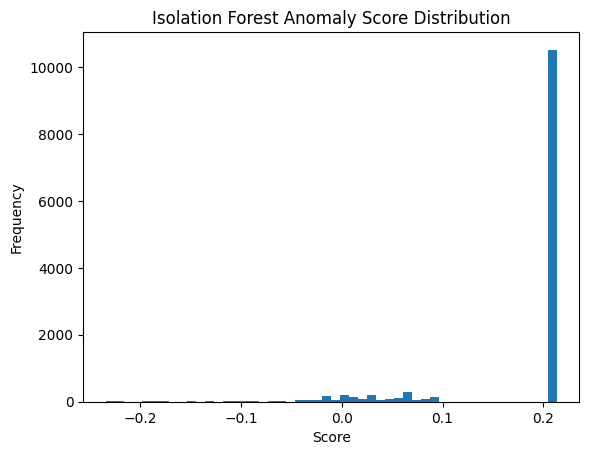

In [40]:
# Anomaly score distribution
scores = model.decision_function(X)

import matplotlib.pyplot as plt

plt.hist(scores, bins=50)
plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()